# Обучение модели RawNet2

## 1. Загрузка данных

In [1]:
import os
import random
from dataclasses import dataclass, field

import numpy as np
import pandas as pd
from scipy.optimize import brentq
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from sklearn.metrics import roc_curve
from IPython.display import clear_output

import torch
import torchaudio
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.nn import BCEWithLogitsLoss

In [2]:
DATASET_PATH = "../russian_sdd_dataset"
SR = 16_000
DEVICE = torch.device("cuda:1") if torch.cuda.is_available() else torch.device("cpu")
print(f"Device set to use: {DEVICE}")

Device set to use: cuda:1


In [3]:
df = pd.read_csv(DATASET_PATH + '/train.csv', index_col=0)
df.head(3)

,audio,tts_model,audio_filter,gender,label,spk_id
0,real/000001.wav,NaN,True,male,0,0
1,fake/000001.wav,F5-TTS,True,male,1,0
2,real/000002.wav,NaN,True,male,0,0


In [4]:
def speaker_independent_split(df: pd.DataFrame, val_ratio: float = 0.15) -> tuple[pd.DataFrame, pd.DataFrame]:
    if not 0 <= val_ratio <= 1:
        raise ValueError(f"Invalid val_ratio: {val_ratio}")
        
    df_ = df.copy()
    unique_speakers = df_['spk_id'].unique()

    train_speakers = set(unique_speakers[:int(len(unique_speakers)*(1-val_ratio))])
    val_speakers = set(unique_speakers[int(len(unique_speakers)*(1-val_ratio)): ])

    df_['split'] = df_['spk_id'].apply(lambda x: "train" if x in train_speakers else "val")

    train_df = df_[df_['split'] == "train"]
    val_df = df_[df_['split'] == "val"]

    return train_df, val_df 

In [5]:
def load_audio(audio_path: str) -> torch.Tensor:
    sample_rate = 16_000
    
    wav, sr = torchaudio.load(audio_path)
        
    if sr != sample_rate:
        wav = torchaudio.transforms.Resample(sr, sample_rate)(wav)
            
    if wav.shape[0] > 1:
        wav = wav.mean(dim=0, keepdim=True)
            
    return wav

In [6]:
train_df, val_df = speaker_independent_split(df, val_ratio = 0.15)

train_paths = [os.path.join(DATASET_PATH, audio) for audio in train_df['audio']]
val_paths = [os.path.join(DATASET_PATH, audio) for audio in val_df['audio']]

train_audios = [load_audio(audio) for audio in tqdm(train_paths)]
val_audios = [load_audio(audio) for audio in tqdm(val_paths)]

train_labels = train_df['label'].tolist()
val_labels = val_df['label'].tolist()

  0%|          | 0/11208 [00:00<?, ?it/s]

  0%|          | 0/1992 [00:00<?, ?it/s]

In [7]:
class RSDDDataset(Dataset):
    def __init__(self, 
                 audios: list[torch.Tensor], 
                 labels: list[int], 
                 mode: str, 
                 sample_rate: int = 16_000, 
                 duration: float = 3.0,
                 rir_folder: str | None = None,
                 rir_proba: float = 0.5):
        """
        :param audios: Список путей к аудиофайлам.
        :param labels: Список меток (0/1).
        :param mode: 'train' или 'val'.
        :param sample_rate: Целевая частота дискретизации.
        :param duration: Длительность сегмента в секундах.
        :param rir_folder: Путь к папке с импульсными откликами (для аугментаций)
        :param rir_proba: Вероятность, с которой к аудио будет применена RIR аугментация
        """
        if mode not in {"train", "val"}:
            raise ValueError(f"Invalid mode: {mode}")
            
        self.audios = audios
        self.labels = labels 
        self.mode = mode  
        self.sample_rate = sample_rate
        self.duration = duration
        self.n_samples = int(sample_rate * duration)
        
        self.rirs = []
        self.rir_proba = rir_proba
        if mode == "train" and rir_folder is not None:
            if not os.path.exists(rir_folder):
                raise ValueError(f"Rir folder does not exist: {rir_folder}")
            self._load_rirs(rir_folder)

    
    def __len__(self):
        return len(self.audios)

    
    def _load_rirs(self, folder: str):
        """Загружает и предобрабатывает импульсные отклики."""            
        files = os.listdir(folder)
        files = [os.path.join(folder, rir_file) for rir_file in files]
        for rir_file in files:
            rir, rir_sr = torchaudio.load(rir_file)
            if rir_sr != self.sample_rate:
                rir = torchaudio.transforms.Resample(rir_sr, self.sample_rate)(rir)
            self.rirs.append(rir)
        

    
    def _load_audio(self, audio_path: str) -> torch.Tensor:
        wav, sr = torchaudio.load(audio_path)
        
        if sr != self.sample_rate:
            wav = torchaudio.transforms.Resample(sr, self.sample_rate)(wav)
            
        if wav.shape[0] > 1:
            wav = wav.mean(dim=0, keepdim=True)
            
        return wav

    
    def _apply_rir(self, wav: torch.Tensor, rir: torch.Tensor):
        """Применяет реверберацию к аудио (симуляция среды)"""
        left_pad = right_pad = rir.shape[-1] - 1
        
        flipped_rir = rir.squeeze().flip(0)
    
        wav = F.pad(wav, [left_pad, right_pad]).view(1, 1, -1)
        wav = torch.conv1d(wav, flipped_rir.view(1, 1, -1)).squeeze()
        
        if wav.abs().max() > 1:
            wav /= wav.abs().max()

        return wav.unsqueeze(0)

    def _apply_rir_fft(self, wav: torch.Tensor, rir: torch.Tensor) -> torch.Tensor:
        """Применяет реверберацию через частотную область (быстрее для длинных RIR)"""
        # Убираем канал, работаем с 1D
        wav_1d = wav.squeeze(0)
        rir_1d = rir.squeeze()
        
        # FFT-свёртка через torch.fft
        wav_fft = torch.fft.rfft(wav_1d, n=wav_1d.shape[-1] + rir_1d.shape[-1] - 1)
        rir_fft = torch.fft.rfft(rir_1d, n=wav_1d.shape[-1] + rir_1d.shape[-1] - 1)
        conv_fft = wav_fft * rir_fft
        convolved = torch.fft.irfft(conv_fft, n=wav_1d.shape[-1] + rir_1d.shape[-1] - 1)
        
        # Обрезаем до исходной длины + паддинга
        valid_length = wav_1d.shape[-1] + rir_1d.shape[-1] - 1
        convolved = convolved[:valid_length]
        
        # Нормализация
        if convolved.abs().max() > 1:
            convolved = convolved / convolved.abs().max()
        
        return convolved.unsqueeze(0)

    
    def _audio_loop(self, wav: torch.Tensor) -> torch.Tensor:
        """Зацикливает аудио, если оно короче нужной длины"""
        n_repeat = self.n_samples // wav.shape[-1] + 1
        wav = wav.repeat(1, n_repeat)
        wav = wav[:, :self.n_samples]
        return wav


    def _process_train(self, wav: torch.Tensor) -> torch.Tensor:
        if self.rirs and random.random() >= self.rir_proba:
            rir = random.choice(self.rirs)
            wav = self._apply_rir_fft(wav, rir)
            
        if wav.shape[-1] > self.n_samples:
            max_index = wav.shape[-1] - self.n_samples
            start_index = random.randint(0, max_index)
            end_index = start_index + self.n_samples 
            wav = wav[:, start_index:end_index]
        else:
            wav = self._audio_loop(wav)
            
        return wav 


    def _process_val(self, wav: torch.Tensor) -> torch.Tensor:
        if wav.shape[-1] >= self.n_samples:
            return wav[:, :self.n_samples]
        else:
            return self._audio_loop(wav)

    
    def __getitem__(self, idx):
        wav = self.audios[idx]
        label = self.labels[idx]

        #wav = self._load_audio(audio_path)

        if self.mode == "train":
            wav = self._process_train(wav)
        else:
            wav = self._process_val(wav)
            
        wav = wav.float()
        
        return wav, torch.tensor(label, dtype=torch.float32)

In [8]:
BATCH_SIZE = 32

In [9]:
train_dataset = RSDDDataset(train_audios, train_labels, mode='train', rir_folder='../rir-data', rir_proba=0.5, duration=5.0)
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, num_workers=4, shuffle=True, pin_memory=True, persistent_workers=True)

val_dataset = RSDDDataset(val_audios, val_labels, mode='val', duration=5.0)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, num_workers=2, shuffle=False, pin_memory=True, persistent_workers=True)

## 2. Архитектура модели

In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import Tensor
import numpy as np
import math
from torch.utils import data
from collections import OrderedDict
from torch.nn.parameter import Parameter
from torch.autograd import Variable
import pickle
import random


class SincConv(nn.Module):
    @staticmethod
    def to_mel(hz):
        return 2595 * np.log10(1 + hz / 700)

    @staticmethod
    def to_hz(mel):
        return 700 * (10 ** (mel / 2595) - 1)


    def __init__(self, device,out_channels, kernel_size,in_channels=1,sample_rate=16000,
                 stride=1, padding=0, dilation=1, bias=False, groups=1,freq_scale='Mel'):

        super(SincConv,self).__init__()


        if in_channels != 1:
            
            msg = "SincConv only support one input channel (here, in_channels = {%i})" % (in_channels)
            raise ValueError(msg)
        
        self.out_channels = out_channels+1
        self.kernel_size = kernel_size
        self.sample_rate=sample_rate

        # Forcing the filters to be odd (i.e, perfectly symmetrics)
        if kernel_size%2==0:
            self.kernel_size=self.kernel_size+1

        self.device=device   
        self.stride = stride
        self.padding = padding
        self.dilation = dilation
        
        if bias:
            raise ValueError('SincConv does not support bias.')
        if groups > 1:
            raise ValueError('SincConv does not support groups.')
        
        
        # initialize filterbanks using Mel scale
        NFFT = 512
        f=int(self.sample_rate/2)*np.linspace(0,1,int(NFFT/2)+1)


        if freq_scale == 'Mel':
            fmel=self.to_mel(f) # Hz to mel conversion
            fmelmax=np.max(fmel)
            fmelmin=np.min(fmel)
            filbandwidthsmel=np.linspace(fmelmin,fmelmax,self.out_channels+2)
            filbandwidthsf=self.to_hz(filbandwidthsmel) # Mel to Hz conversion
            self.freq=filbandwidthsf[:self.out_channels]

        elif freq_scale == 'Inverse-mel':
            fmel=self.to_mel(f) # Hz to mel conversion
            fmelmax=np.max(fmel)
            fmelmin=np.min(fmel)
            filbandwidthsmel=np.linspace(fmelmin,fmelmax,self.out_channels+2)
            filbandwidthsf=self.to_hz(filbandwidthsmel) # Mel to Hz conversion
            self.mel=filbandwidthsf[:self.out_channels]
            self.freq=np.abs(np.flip(self.mel)-1) ## invert mel scale

        
        else:
            fmelmax=np.max(f)
            fmelmin=np.min(f)
            filbandwidthsmel=np.linspace(fmelmin,fmelmax,self.out_channels+2)
            self.freq=filbandwidthsmel[:self.out_channels]
        
        self.hsupp=torch.arange(-(self.kernel_size-1)/2, (self.kernel_size-1)/2+1)
        self.band_pass=torch.zeros(self.out_channels-1,self.kernel_size)
       
        
    def forward(self,x):
        for i in range(len(self.freq)-1):
            fmin=self.freq[i]
            fmax=self.freq[i+1]
            hHigh=(2*fmax/self.sample_rate)*np.sinc(2*fmax*self.hsupp/self.sample_rate)
            hLow=(2*fmin/self.sample_rate)*np.sinc(2*fmin*self.hsupp/self.sample_rate)
            hideal=hHigh-hLow
            
            self.band_pass[i,:]=Tensor(np.hamming(self.kernel_size))*Tensor(hideal)
        
        band_pass_filter=self.band_pass.to(self.device)

        self.filters = (band_pass_filter).view(self.out_channels-1, 1, self.kernel_size)
        
        return F.conv1d(x, self.filters, stride=self.stride,
                        padding=self.padding, dilation=self.dilation,
                         bias=None, groups=1)


        
class Residual_block(nn.Module):
    def __init__(self, nb_filts, first = False):
        super(Residual_block, self).__init__()
        self.first = first
        
        if not self.first:
            self.bn1 = nn.BatchNorm1d(num_features = nb_filts[0])
        
        self.lrelu = nn.LeakyReLU(negative_slope=0.3)
        
        self.conv1 = nn.Conv1d(in_channels = nb_filts[0],
			out_channels = nb_filts[1],
			kernel_size = 3,
			padding = 1,
			stride = 1)
        
        self.bn2 = nn.BatchNorm1d(num_features = nb_filts[1])
        self.conv2 = nn.Conv1d(in_channels = nb_filts[1],
			out_channels = nb_filts[1],
			padding = 1,
			kernel_size = 3,
			stride = 1)
        
        if nb_filts[0] != nb_filts[1]:
            self.downsample = True
            self.conv_downsample = nn.Conv1d(in_channels = nb_filts[0],
				out_channels = nb_filts[1],
				padding = 0,
				kernel_size = 1,
				stride = 1)
            
        else:
            self.downsample = False
        self.mp = nn.MaxPool1d(3)
        
    def forward(self, x):
        identity = x
        if not self.first:
            out = self.bn1(x)
            out = self.lrelu(out)
        else:
            out = x
            
        out = self.conv1(out)
        out = self.bn2(out)
        out = self.lrelu(out)
        out = self.conv2(out)
        
        if self.downsample:
            identity = self.conv_downsample(identity)
            
        out += identity
        out = self.mp(out)
        return out


class RawNet(nn.Module):
    def __init__(self, d_args, device):
        super(RawNet, self).__init__()

        self.device=device

        self.Sinc_conv=SincConv(device=self.device,
			out_channels = d_args['filts'][0],
			kernel_size = d_args['first_conv'],
                        in_channels = d_args['in_channels'],freq_scale='Mel'
        )
        
        self.first_bn = nn.BatchNorm1d(num_features = d_args['filts'][0])
        self.selu = nn.SELU(inplace=True)
        self.block0 = nn.Sequential(Residual_block(nb_filts = d_args['filts'][1], first = True))
        self.block1 = nn.Sequential(Residual_block(nb_filts = d_args['filts'][1]))
        self.block2 = nn.Sequential(Residual_block(nb_filts = d_args['filts'][2]))
        d_args['filts'][2][0] = d_args['filts'][2][1]
        self.block3 = nn.Sequential(Residual_block(nb_filts = d_args['filts'][2]))
        self.block4 = nn.Sequential(Residual_block(nb_filts = d_args['filts'][2]))
        self.block5 = nn.Sequential(Residual_block(nb_filts = d_args['filts'][2]))
        self.avgpool = nn.AdaptiveAvgPool1d(1)

        self.fc_attention0 = self._make_attention_fc(in_features = d_args['filts'][1][-1],
            l_out_features = d_args['filts'][1][-1])
        self.fc_attention1 = self._make_attention_fc(in_features = d_args['filts'][1][-1],
            l_out_features = d_args['filts'][1][-1])
        self.fc_attention2 = self._make_attention_fc(in_features = d_args['filts'][2][-1],
            l_out_features = d_args['filts'][2][-1])
        self.fc_attention3 = self._make_attention_fc(in_features = d_args['filts'][2][-1],
            l_out_features = d_args['filts'][2][-1])
        self.fc_attention4 = self._make_attention_fc(in_features = d_args['filts'][2][-1],
            l_out_features = d_args['filts'][2][-1])
        self.fc_attention5 = self._make_attention_fc(in_features = d_args['filts'][2][-1],
            l_out_features = d_args['filts'][2][-1])

        self.bn_before_gru = nn.BatchNorm1d(num_features = d_args['filts'][2][-1])
        self.gru = nn.GRU(input_size = d_args['filts'][2][-1],
			hidden_size = d_args['gru_node'],
			num_layers = d_args['nb_gru_layer'],
			batch_first = True)
        
        self.fc1_gru = nn.Linear(in_features = d_args['gru_node'],
			out_features = d_args['nb_fc_node'])
       
        self.fc2_gru = nn.Linear(in_features = d_args['nb_fc_node'], out_features = 1, bias=True)
       
        self.sig = nn.Sigmoid()
        
        
    def forward(self, x):        
        x = self.Sinc_conv(x)    # Fixed sinc filters convolution
        x = F.max_pool1d(torch.abs(x), 3)
        x = self.first_bn(x)
        x = self.selu(x)
        
        x0 = self.block0(x)
        y0 = self.avgpool(x0).view(x0.size(0), -1) # torch.Size([batch, filter])
        y0 = self.fc_attention0(y0)
        y0 = self.sig(y0).view(y0.size(0), y0.size(1), -1)  # torch.Size([batch, filter, 1])
        x = x0 * y0 + y0  # (batch, filter, time) x (batch, filter, 1)
        

        x1 = self.block1(x)
        y1 = self.avgpool(x1).view(x1.size(0), -1) # torch.Size([batch, filter])
        y1 = self.fc_attention1(y1)
        y1 = self.sig(y1).view(y1.size(0), y1.size(1), -1)  # torch.Size([batch, filter, 1])
        x = x1 * y1 + y1 # (batch, filter, time) x (batch, filter, 1)

        x2 = self.block2(x)
        y2 = self.avgpool(x2).view(x2.size(0), -1) # torch.Size([batch, filter])
        y2 = self.fc_attention2(y2)
        y2 = self.sig(y2).view(y2.size(0), y2.size(1), -1)  # torch.Size([batch, filter, 1])
        x = x2 * y2 + y2 # (batch, filter, time) x (batch, filter, 1)

        x3 = self.block3(x)
        y3 = self.avgpool(x3).view(x3.size(0), -1) # torch.Size([batch, filter])
        y3 = self.fc_attention3(y3)
        y3 = self.sig(y3).view(y3.size(0), y3.size(1), -1)  # torch.Size([batch, filter, 1])
        x = x3 * y3 + y3 # (batch, filter, time) x (batch, filter, 1)

        x4 = self.block4(x)
        y4 = self.avgpool(x4).view(x4.size(0), -1) # torch.Size([batch, filter])
        y4 = self.fc_attention4(y4)
        y4 = self.sig(y4).view(y4.size(0), y4.size(1), -1)  # torch.Size([batch, filter, 1])
        x = x4 * y4 + y4 # (batch, filter, time) x (batch, filter, 1)

        x5 = self.block5(x)
        y5 = self.avgpool(x5).view(x5.size(0), -1) # torch.Size([batch, filter])
        y5 = self.fc_attention5(y5)
        y5 = self.sig(y5).view(y5.size(0), y5.size(1), -1)  # torch.Size([batch, filter, 1])
        x = x5 * y5 + y5 # (batch, filter, time) x (batch, filter, 1)

        x = self.bn_before_gru(x)
        x = self.selu(x)
        x = x.permute(0, 2, 1)     #(batch, filt, time) >> (batch, time, filt)
        self.gru.flatten_parameters()
        x, _ = self.gru(x)
        x = x[:,-1,:]
        x = self.fc1_gru(x)
        x = self.fc2_gru(x)

        return x
        

    def _make_attention_fc(self, in_features, l_out_features):
        l_fc = []
        
        l_fc.append(nn.Linear(in_features = in_features,
			        out_features = l_out_features))

        return nn.Sequential(*l_fc)


    def _make_layer(self, nb_blocks, nb_filts, first = False):
        layers = []
        for i in range(nb_blocks):
            first = first if i == 0 else False
            layers.append(Residual_block(nb_filts = nb_filts,
				first = first))
            if i == 0: nb_filts[0] = nb_filts[1]
            
        return nn.Sequential(*layers)

In [11]:
from torchinfo import summary

d_args = {
  "nb_samp": 80000,
  "first_conv": 1024,   
  "in_channels": 1,
  "filts": [20, [20, 20], [20, 128], [128, 128]],
  "blocks": [2, 4],
  "nb_fc_node": 1024,
  "gru_node": 1024,
  "nb_gru_layer": 3,
}
model = RawNet(d_args, device=DEVICE).to(DEVICE)

summary(model)

Layer (type:depth-idx)                   Param #
RawNet                                   --
├─SincConv: 1-1                          --
├─BatchNorm1d: 1-2                       40
├─SELU: 1-3                              --
├─Sequential: 1-4                        --
│    └─Residual_block: 2-1               --
│    │    └─LeakyReLU: 3-1               --
│    │    └─Conv1d: 3-2                  1,220
│    │    └─BatchNorm1d: 3-3             40
│    │    └─Conv1d: 3-4                  1,220
│    │    └─MaxPool1d: 3-5               --
├─Sequential: 1-5                        --
│    └─Residual_block: 2-2               --
│    │    └─BatchNorm1d: 3-6             40
│    │    └─LeakyReLU: 3-7               --
│    │    └─Conv1d: 3-8                  1,220
│    │    └─BatchNorm1d: 3-9             40
│    │    └─Conv1d: 3-10                 1,220
│    │    └─MaxPool1d: 3-11              --
├─Sequential: 1-6                        --
│    └─Residual_block: 2-3               --
│    │    └─Bat

## 3. Обучение

In [12]:
def calculate_eer(y_true, y_probas):
    """Рассчитывает EER и соответствующий порог"""
    fpr, tpr, thresholds = roc_curve(y_true, y_probas, pos_label=1)
    
    eer = brentq(lambda x: 1. - x - interp1d(fpr, tpr)(x), 0., 1.)
    thresh = interp1d(fpr, thresholds)(eer)
    
    return fpr, tpr, thresholds, eer, thresh

In [13]:
@dataclass
class Metrics:
    train_loss: list[float] = field(default_factory=list)
    val_loss: list[float] = field(default_factory=list)
    val_eer: list[float] = field(default_factory=list)


def plot_metrics(metrics: Metrics):
    clear_output(True)
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    axes[0].set_title("Train Loss")
    axes[0].plot(range(len(metrics.train_loss)), metrics.train_loss, color='blue')
    axes[0].grid()

    axes[1].set_title("Val Loss")
    axes[1].plot(range(len(metrics.val_loss)), metrics.val_loss, color='green')
    axes[1].grid()
    
    axes[2].set_title("Val EER")
    axes[2].plot(range(len(metrics.val_eer)), metrics.val_eer, color='red')
    axes[2].grid()
    plt.show()
    
    

def eval_epoch(epoch, model, loss_fn, val_dataloader):
    model.eval()
    total_loss = 0.0
    batch_cntr = 0
    predictions = []
    true_labels = []
    
    device = DEVICE
    
    with torch.no_grad():
        for batch in tqdm(val_dataloader, desc=f"Epoch {epoch}: validation", leave=False):
            inputs, targets = batch[0].to(DEVICE), batch[1].to(DEVICE)
            
            outputs = model(inputs).squeeze()
            loss = loss_fn(outputs, targets)
            
            total_loss += loss.item()
            
            predictions.extend(outputs.cpu().numpy())
            true_labels.extend(targets.cpu().numpy())

            batch_cntr += 1
            
    avg_loss = total_loss / batch_cntr
    _, _, _, eer, _ = calculate_eer(np.array(true_labels), np.array(predictions))
    
    return avg_loss, eer


def train_epoch(epoch, model, optimizer, loss_fn, train_dataloader):
    model.train()
    total_loss = 0.0
    batch_cntr = 0
    
    for batch in tqdm(train_dataloader, desc=f"Epoch {epoch}: training", leave=False):
        inputs, targets = batch[0].to(DEVICE), batch[1].to(DEVICE)
        
        optimizer.zero_grad()
        outputs = model(inputs).squeeze()
        loss = loss_fn(outputs, targets)
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        batch_cntr += 1
        
    avg_loss = total_loss / batch_cntr
    return avg_loss
    

def train(model, optimizer, loss_fn, train_dataloader, val_dataloader, n_epochs=20, early_stopping=3, checkpoint_path = "./best_model.pt"):
    metrics = Metrics()
    best_eer = 1.0 
    best_eer_epoch = -1
    best_train_loss = 10**10
    best_val_loss = 10**10
    early_stopping_cntr = 0

    for epoch in tqdm(range(n_epochs)):
        train_loss = train_epoch(epoch + 1, model, optimizer, loss_fn, train_dataloader)
        val_loss, val_eer = eval_epoch(epoch + 1, model, loss_fn, val_dataloader)
        
        metrics.train_loss.append(train_loss)
        metrics.val_loss.append(val_loss)
        metrics.val_eer.append(val_eer)

        if val_eer < best_eer:
            early_stopping_cntr = 0
            best_eer = val_eer 
            best_eer_epoch = epoch 

            if checkpoint_path:
                torch.save({'model_state_dict': model.state_dict()}, checkpoint_path)
        else:
            early_stopping_cntr += 1
            
        best_train_loss = min(best_train_loss, train_loss)
        best_val_loss = min(best_val_loss, val_loss)

        plot_metrics(metrics)
        print(f"Current train loss: {train_loss}  |  Best: {best_train_loss}")
        print(f"Current validation loss: {val_loss}  |  Best: {best_val_loss}")
        print(f"Current validation EER: {val_eer}  |  Best EER: {best_eer}  |  Best epoch: {best_eer_epoch + 1}")

        if early_stopping_cntr == early_stopping:
            print("Early stopping!")
            break 
            
    return metrics

In [14]:
optimizer = AdamW(model.parameters(), lr=0.0001)
loss_fn = BCEWithLogitsLoss()

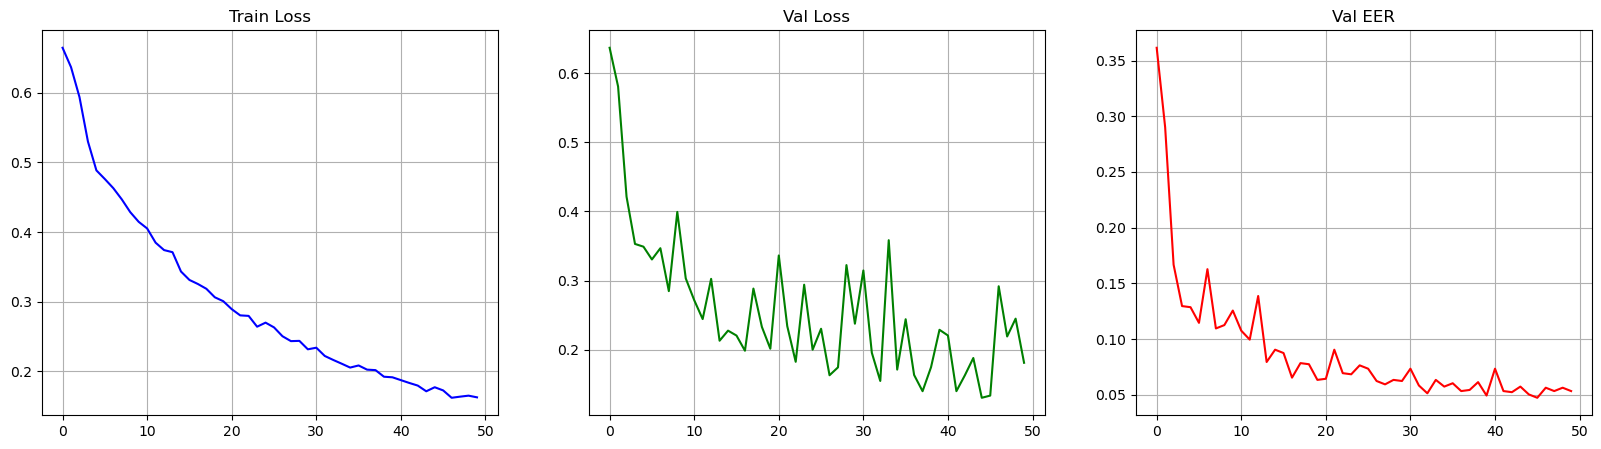

Current train loss: 0.16250550624333385  |  Best: 0.16188045244058993
Current validation loss: 0.1809490103540676  |  Best: 0.13031544270259993
Current validation EER: 0.0532128514057816  |  Best EER: 0.04718875502008037  |  Best epoch: 46


In [15]:
metrics = train(
    model, 
    optimizer, 
    loss_fn, 
    train_dataloader, 
    val_dataloader,
    n_epochs=50,
    early_stopping=7,
    checkpoint_path='rawnet2.pt')

In [16]:
metrics_df = pd.DataFrame()

metrics_df['train_loss'] = metrics.train_loss
metrics_df['val_loss'] = metrics.val_loss
metrics_df['val_eer'] = metrics.val_eer

metrics_df.to_csv("rawnet2_metrics.csv")